In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('PlayTennis.csv')
df.head()

,Outlook,Temperature,Humidity,Wind,PlayTennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes


In [18]:
# Encode categorical variables
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['Outlook'] = le.fit_transform(df['Outlook'])
df['Temperature'] = le.fit_transform(df['Temperature'])
df['Humidity'] = le.fit_transform(df['Humidity'])
df['Wind'] = le.fit_transform(df['Wind'])
df['PlayTennis'] = le.fit_transform(df['PlayTennis'])

# Separate features and target variable
x = df.drop('PlayTennis', axis=1)
y = df['PlayTennis']
x

,Outlook,Temperature,Humidity,Wind
0,2,1,0,1
1,2,1,0,0
2,0,1,0,1
3,1,2,0,1
4,1,0,1,1
5,1,0,1,0
6,0,0,1,0
7,2,2,0,1
8,2,0,1,1
9,1,2,1,1


Classification Report (Entropy):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3

Accuracy Score (Entropy): 1.0
Matthews Correlation Coefficient (Entropy): 1.0


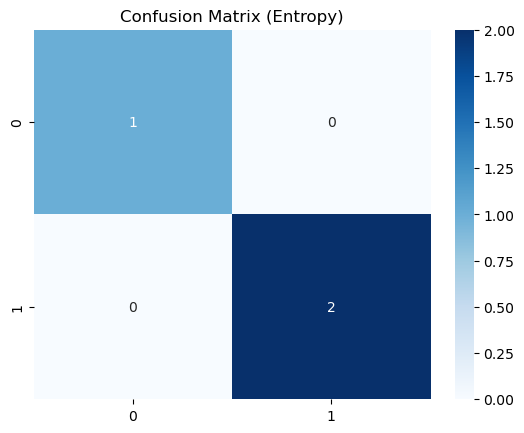

In [21]:
# Split the dataset
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Decision Tree Classifier with entropy
from sklearn.tree import DecisionTreeClassifier
dtc_entropy = DecisionTreeClassifier(criterion="entropy", random_state=42)
dtc_entropy.fit(x_train,y_train)
y_pred_entropy = dtc_entropy.predict(x_test)

# Metrics for entropy-based classifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, matthews_corrcoef
print("Classification Report (Entropy):")
print(classification_report(y_test, y_pred_entropy))
print("Accuracy Score (Entropy):", accuracy_score(y_test, y_pred_entropy))
print("Matthews Correlation Coefficient (Entropy):", matthews_corrcoef(y_test, y_pred_entropy))

# Confusion matrix heatmap for entropy-based classifier
sns.heatmap(confusion_matrix(y_test, y_pred_entropy), annot=True, cmap='Blues')
plt.title('Confusion Matrix (Entropy)')
plt.show()

Classification Report (Gini):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3

Accuracy Score (Gini): 1.0
Matthews Correlation Coefficient (Gini): 1.0


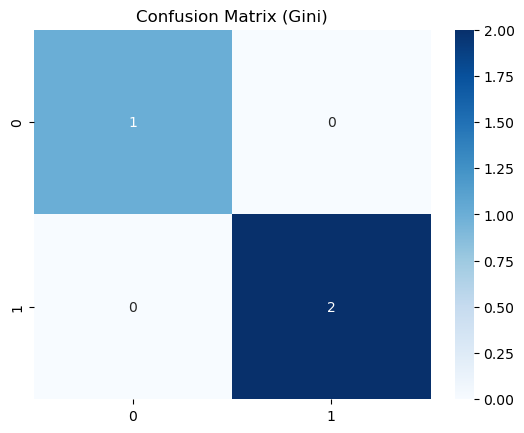

In [22]:
# Decision Tree Classifier with gini
dtc_gini = DecisionTreeClassifier(criterion="gini", random_state=42)
dtc_gini.fit(x_train, y_train)
y_pred_gini = dtc_gini.predict(x_test)

# Metrics for gini-based classifier
print("Classification Report (Gini):")
print(classification_report(y_test, y_pred_gini))
print("Accuracy Score (Gini):", accuracy_score(y_test, y_pred_gini))
print("Matthews Correlation Coefficient (Gini):", matthews_corrcoef(y_test, y_pred_gini))

# Confusion matrix heatmap for gini-based classifier
sns.heatmap(confusion_matrix(y_test, y_pred_gini), annot=True, cmap='Blues')
plt.title('Confusion Matrix (Gini)')
plt.show()

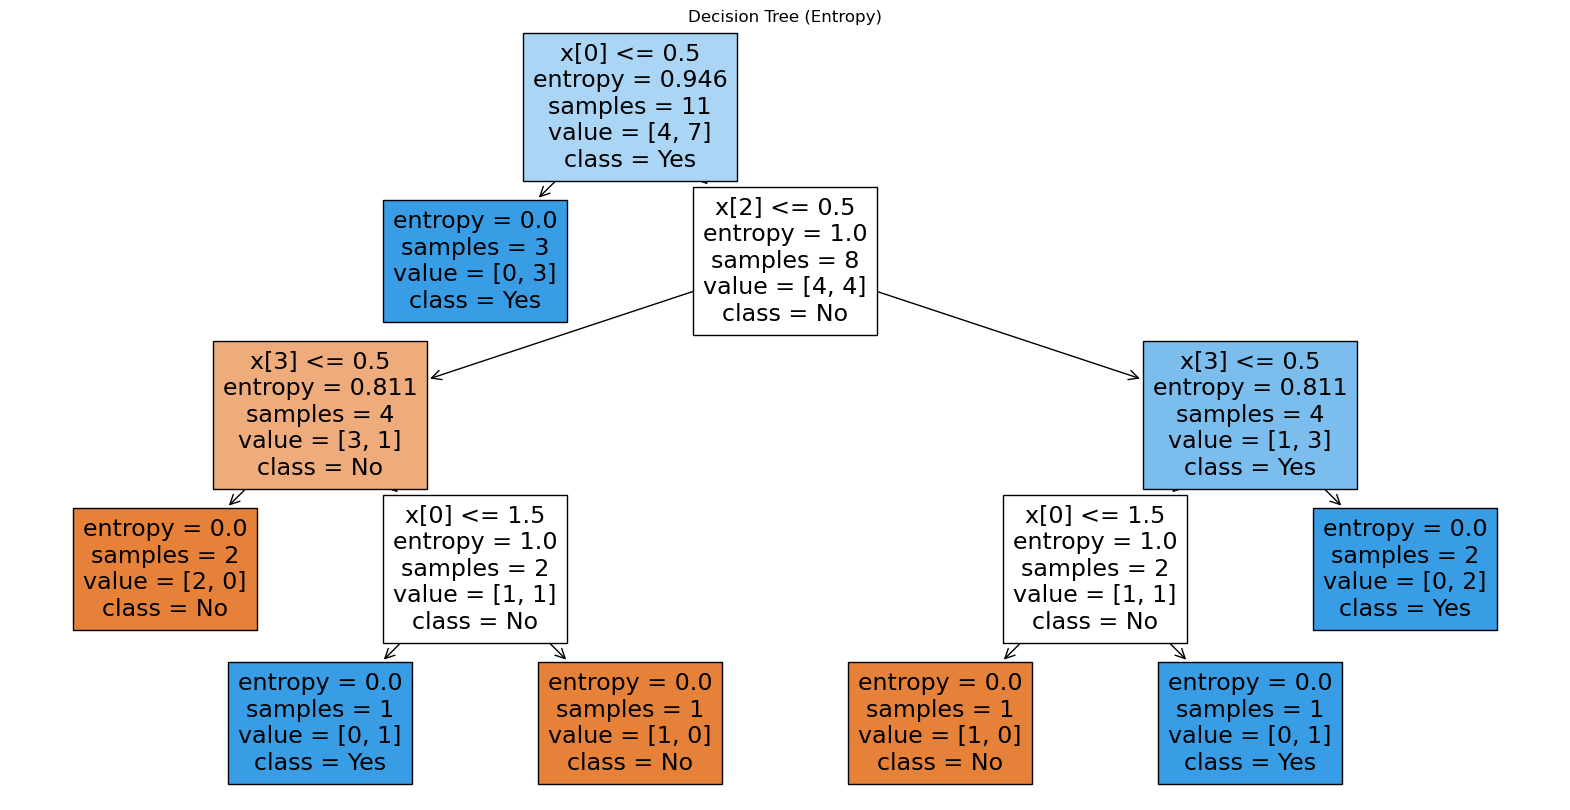

In [30]:
# Plotting the trees
from sklearn.tree import plot_tree

# Plot tree for entropy-based classifier
plt.figure(figsize=(20,10))
plot_tree(dtc_entropy, class_names=['No', 'Yes'], filled=True)
plt.title('Decision Tree (Entropy)')
plt.show()

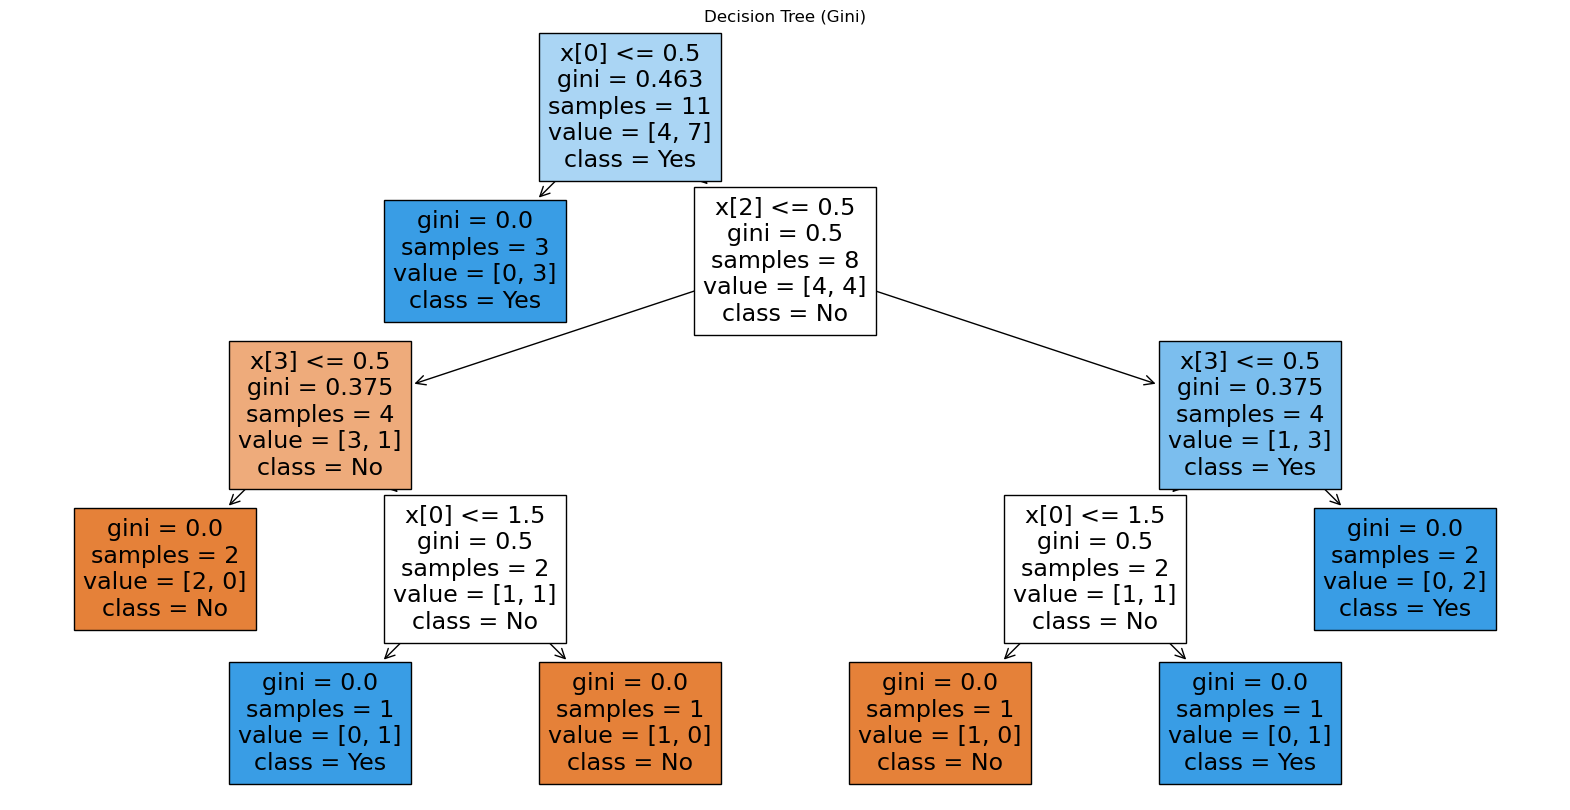

In [29]:
# Plot tree for gini-based classifier
plt.figure(figsize=(20,10))
plot_tree(dtc_gini, class_names=['No', 'Yes'], filled=True)
plt.title('Decision Tree (Gini)')
plt.show()
